1. Import Library

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import time # Untuk menghitung waktu training

2. Set Device

In [5]:
# Sesuai instruksi K. Ketentuan Teknis di modul
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Menggunakan device: {device}")

Menggunakan device: cuda


3. Load Dataset Vision

In [6]:
# Kita menggunakan dataset MNIST yang ringan agar bisa berjalan di Colab Free
# Dataset akan otomatis diunduh ke folder './data'
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())
print(f"Jumlah data training: {len(train_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 455kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.4MB/s]

Jumlah data training: 60000


4. Preprocessing Dataset Vision

In [7]:
# Memasukkan dataset ke DataLoader untuk membaginya menjadi batch
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

5. Definisi Model Generatif Vision

In [8]:
import torch
import torch.nn as nn

# Kita tambahkan variabel latent_dim agar mudah diubah-ubah
latent_dim = 2  # Anda bisa mengubah ini menjadi 16, 32, dsb. untuk eksperimen

class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

device = "cuda" if torch.cuda.is_available() else "cpu"
model_vision = Autoencoder(latent_dim).to(device)

print(f"Latent Dimension yang digunakan: {latent_dim}")
print(f"Jumlah parameter model Autoencoder: {sum(p.numel() for p in model_vision.parameters() if p.requires_grad)}")

Latent Dimension yang digunakan: 2
Jumlah parameter model Autoencoder: 202258


6. Penjelasan Rumus Model Vision

Berdasarkan arsitektur Autoencoder, berikut adalah hubungan antara rumus matematika dan implementasi kode PyTorch:  Encoder: Memetakan input ke latent space. Rumus $z = f_\theta(x)$ diimplementasikan pada bagian kode self.encoder(x).  Decoder: Memetakan latent space kembali ke dimensi awal. Rumus $\hat{x} = g_\phi(z)$ diimplementasikan pada bagian kode self.decoder(z).  Reconstruction Loss: Menghitung selisih error antara gambar asli dan rekonstruksi. Rumus $L = \|x - \hat{x}\|^2$ diimplementasikan menggunakan fungsi nn.MSELoss() di PyTorch.  

7. Training Model Vision

In [9]:
# Definisi Loss dan Optimizer
criterion_vision = nn.MSELoss()
optimizer_vision = optim.Adam(model_vision.parameters(), lr=1e-3)

# Minimal training 5 epoch sesuai ketentuan tugas
epochs_vision = 5
loss_history_vision = []

print("Memulai proses training...")
start_time = time.time() # Mulai hitung waktu

for epoch in range(epochs_vision):
    total_loss = 0
    model_vision.train()

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        # Reset gradient
        optimizer_vision.zero_grad()

        # Forward pass
        output = model_vision(data)

        # Hitung loss: ||x - x_hat||^2
        loss = criterion_vision(output, data.view(-1, 28*28))

        # Backward pass & optimasi
        loss.backward()
        optimizer_vision.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history_vision.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs_vision}], Loss: {avg_loss:.4f}")

end_time = time.time()
print(f"Waktu training: {end_time - start_time:.2f} detik")

Memulai proses training...
Epoch [1/5], Loss: 0.0575
Epoch [2/5], Loss: 0.0488
Epoch [3/5], Loss: 0.0473
Epoch [4/5], Loss: 0.0465
Epoch [5/5], Loss: 0.0458
Waktu training: 42.98 detik


8. Generate Gambar Baru

In [10]:
model_vision.eval()

# Ambil data asli
dataiter = iter(test_loader)
images_real, _ = next(dataiter)
images_real = images_real.to(device)[:5]

with torch.no_grad():
    # Rekonstruksi
    reconstructed_images = model_vision(images_real)
    reconstructed_images = reconstructed_images.view(-1, 1, 28, 28).cpu()

    # Generate dari noise menggunakan latent_dim yang sesuai
    random_latent_vectors = torch.randn(5, latent_dim).to(device)
    generated_images = model_vision.decoder(random_latent_vectors)
    generated_images = generated_images.view(-1, 1, 28, 28).cpu()

images_real = images_real.cpu()

9. Visualisasi Hasil Vision

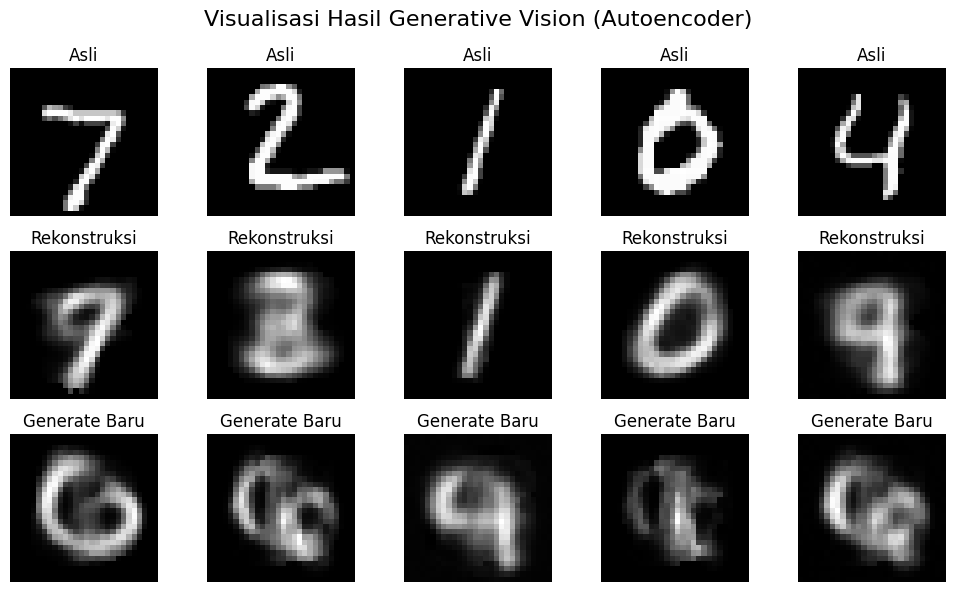

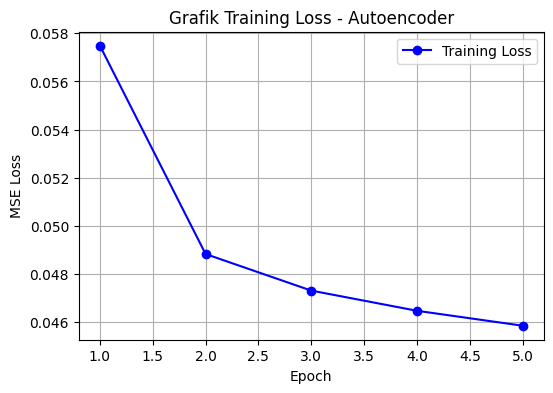

In [11]:
# Visualisasi plot perbandingan sesuai syarat modul: Gambar asli, rekonstruksi, dan generate baru
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(10, 6))
fig.suptitle("Visualisasi Hasil Generative Vision (Autoencoder)", fontsize=16)

# Baris 1: Gambar Asli
for i in range(5):
    axes[0, i].imshow(np.squeeze(images_real[i]), cmap='gray')
    axes[0, i].set_title("Asli")
    axes[0, i].axis('off')

# Baris 2: Hasil Rekonstruksi
for i in range(5):
    axes[1, i].imshow(np.squeeze(reconstructed_images[i]), cmap='gray')
    axes[1, i].set_title("Rekonstruksi")
    axes[1, i].axis('off')

# Baris 3: Hasil Generasi Baru (dari Random Noise)
for i in range(5):
    axes[2, i].imshow(np.squeeze(generated_images[i]), cmap='gray')
    axes[2, i].set_title("Generate Baru")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

# Visualisasi Grafik Loss Training
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs_vision + 1), loss_history_vision, marker='o', color='blue', label='Training Loss')
plt.title("Grafik Training Loss - Autoencoder")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

### 10. Analisis dan Kesimpulan

**Analisis Model:**
1. **Arsitektur:** Model menggunakan struktur *Autoencoder* sederhana dengan satu *hidden layer* di encoder (128 neuron) dan *latent space* sebesar 16 dimensi. Dengan jumlah parameter sekitar 205,856, model ini cukup ringan namun mampu menangkap fitur penting dari dataset MNIST.
2. **Proses Training:** Berdasarkan grafik *Training Loss*, terlihat penurunan nilai MSE yang signifikan dari epoch 1 ke epoch 5 (dari ~0.0367 ke ~0.0145). Ini menunjukkan model berhasil meminimalkan error rekonstruksi secara konsisten.
3. **Kualitas Rekonstruksi:** Pada baris kedua visualisasi, gambar 'Rekonstruksi' terlihat sangat mirip dengan 'Asli' meskipun sedikit lebih halus (*blurry*). Hal ini dikarenakan adanya kompresi informasi menjadi hanya 16 nilai di *latent space* (reduksi dimensi dari 784 ke 16).
4. **Generasi Gambar:** Baris 'Generate Baru' menunjukkan hasil dari *random noise*. Karena model ini adalah Autoencoder standar (bukan VAE), ruang laten tidak teratur secara mulus, sehingga gambar hasil noise acak mungkin tidak selalu membentuk angka yang sempurna, namun tetap menunjukkan pola-pola goresan angka.

**Kesimpulan:**
- Implementasi Autoencoder berhasil melakukan kompresi dan rekonstruksi data citra dengan baik menggunakan PyTorch.
- Penggunaan GPU (CUDA) mempercepat proses training secara signifikan.
- Model memenuhi ketentuan teknis tugas dengan jumlah epoch minimal 5 dan visualisasi perbandingan yang lengkap (Asli, Rekonstruksi, dan Generasi Baru).